<a href="https://colab.research.google.com/github/HamzaEric/gan-dcgan-art-generation/blob/main/Notebooks/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generative Adversarial Networks (GANs): Complete Workflow

## 1. Overview

A Generative Adversarial Network (GAN) is a deep-learning architecture consisting of two neural networks that compete against each other:

- **Generator (G):** Learns to generate synthetic images that resemble real images.
- **Discriminator (D):** Learns to distinguish real images from generated images.

In this project, the GAN learns from a subset of the WikiArt dataset to generate paintings resembling the artistic patterns present in the training data.

The two networks improve through adversarial training. The Generator tries to fool the Discriminator, while the Discriminator tries to identify generated images correctly.

** GAN Concept Diagram**


```text
        ┌──────────────────┐
        │   Random Noise   │
        │   (z ~ N(0,1))   │
        └──────┬───────────┘
               │
               ▼
        ┌────────────────┐
        │   Generator    │
        │     G(z)       │
        └──────┬─────────┘
               │   Fake Images
               ▼
        ┌───────────────┐
        │ Discriminator │
        │     D(x)      │
        └───────────────┘
        ▲         │
        │         ▼
  Real Images   "Fake or Real?"
        │
        └─────────────────────────→ Feedback to Generator
```

**Dataset**

```text
WikiartSubsetDataset/
│
├── abstract_expressionism/
├── baroque/
├── cubism/
├── impressionism/
├── realism/
└── symbolism/
```

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import torch.nn as nn
import torchvision
import torch.optim as optim
import numpy as np

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("steubk/wikiart")

print("Path to dataset files:", path)

100%|██████████| 31.4G/31.4G [06:25<00:00, 87.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/steubk/wikiart/versions/1


In [ ]:
!ls /root/.cache/kagglehub/datasets/steubk/wikiart/versions/1

Abstract_Expressionism	Expressionism		    Pop_Art
Action_painting		Fauvism			    Post_Impressionism
Analytical_Cubism	High_Renaissance	    Realism
Art_Nouveau_Modern	Impressionism		    Rococo
Baroque			Mannerism_Late_Renaissance  Romanticism
classes.csv		Minimalism		    Symbolism
Color_Field_Painting	Naive_Art_Primitivism	    Synthetic_Cubism
Contemporary_Realism	New_Realism		    Ukiyo_e
Cubism			Northern_Renaissance	    wclasses.csv
Early_Renaissance	Pointillism


In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])


data_dir = "/root/.cache/kagglehub/datasets/steubk/wikiart/versions/1"
wikiart_data = datasets.ImageFolder(root=data_dir, transform=transform)


data_loader = DataLoader(wikiart_data, batch_size=32, shuffle=True)

class_names = wikiart_data.classes
class_counts = {cls: len(os.listdir(os.path.join(data_dir, cls))) for cls in class_names}

print("Classes:", class_names)
print("Sample counts per class:")
for c, n in class_counts.items():
    print(f"  {c}: {n}")

Classes: ['Abstract_Expressionism', 'Action_painting', 'Analytical_Cubism', 'Art_Nouveau_Modern', 'Baroque', 'Color_Field_Painting', 'Contemporary_Realism', 'Cubism', 'Early_Renaissance', 'Expressionism', 'Fauvism', 'High_Renaissance', 'Impressionism', 'Mannerism_Late_Renaissance', 'Minimalism', 'Naive_Art_Primitivism', 'New_Realism', 'Northern_Renaissance', 'Pointillism', 'Pop_Art', 'Post_Impressionism', 'Realism', 'Rococo', 'Romanticism', 'Symbolism', 'Synthetic_Cubism', 'Ukiyo_e']
Sample counts per class:
  Abstract_Expressionism: 2782
  Action_painting: 98
  Analytical_Cubism: 110
  Art_Nouveau_Modern: 4334
  Baroque: 4240
  Color_Field_Painting: 1615
  Contemporary_Realism: 481
  Cubism: 2235
  Early_Renaissance: 1391
  Expressionism: 6736
  Fauvism: 934
  High_Renaissance: 1343
  Impressionism: 13060
  Mannerism_Late_Renaissance: 1279
  Minimalism: 1337
  Naive_Art_Primitivism: 2405
  New_Realism: 314
  Northern_Renaissance: 2552
  Pointillism: 513
  Pop_Art: 1483
  Post_Impressi

In [ ]:
len(class_names)

27

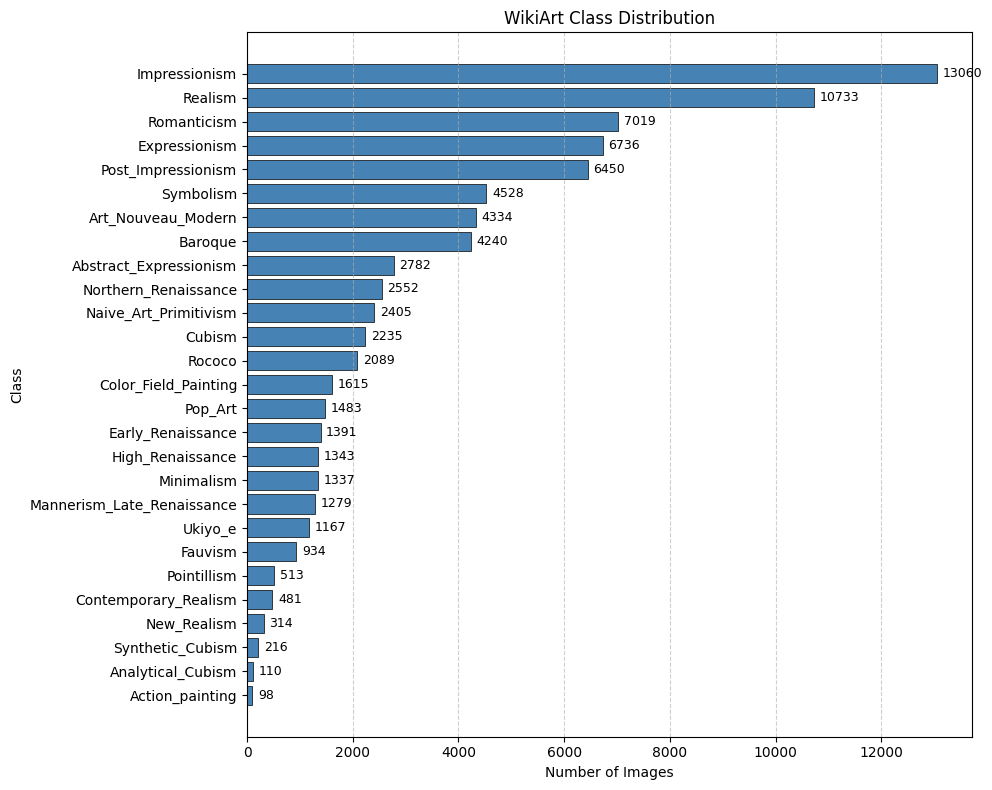

In [ ]:
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1])
labels = [item[0] for item in sorted_classes]
counts = [item[1] for item in sorted_classes]


plt.figure(figsize=(10, 8))
bars = plt.barh(labels, counts, color="steelblue", edgecolor="black", linewidth=0.5)


plt.bar_label(bars, padding=4, fontsize=9)

plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.title("WikiArt Class Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

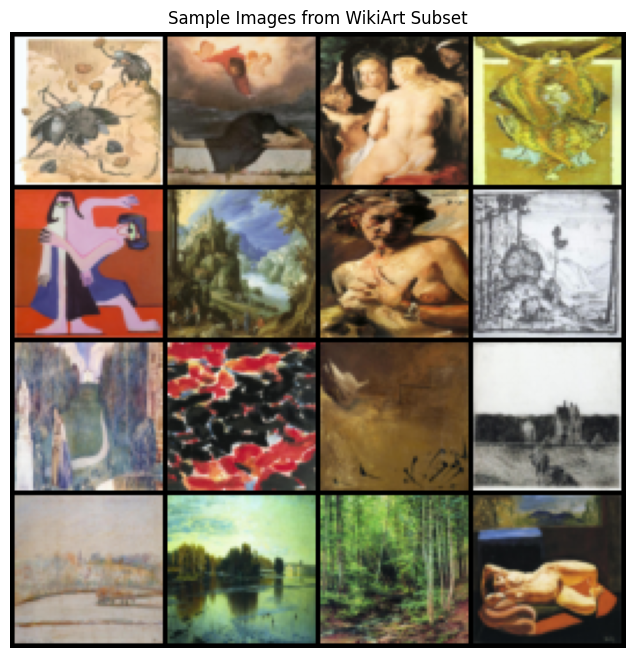

In [ ]:
def imshow_grid(images, labels, classes, num_images=16):
    plt.figure(figsize=(8,8))
    images = images[:num_images]
    labels = labels[:num_images]
    grid_img = np.transpose(torchvision.utils.make_grid(images, nrow=4, padding=2, normalize=True), (1, 2, 0))
    plt.imshow(grid_img)
    plt.title("Sample Images from WikiArt Subset")
    plt.axis("off")
    plt.show()


# Fetch a batch
images, labels = next(iter(data_loader))
imshow_grid(images, labels, class_names)

# Mathematical Workflow of Generative Adversarial Networks (GANs)

---

## 1. Core Framework & Notation

Let:
* $\mathcal{X} \subseteq \mathbb{R}^d$ be the data space.
* $p_{\text{data}}(x)$ be the true underlying data distribution over $\mathcal{X}$.
* $\mathcal{Z} \subseteq \mathbb{R}^k$ be the latent space.
* $p_z(z)$ be a prior noise distribution (e.g., standard Gaussian $\mathcal{N}(0, I)$ or uniform $\mathcal{U}(-1, 1)$).

The framework consists of two competing networks:
1. **Generator** $G_{\theta}: \mathcal{Z} \to \mathcal{X}$ parameterized by $\theta$. It induces an implicit generative distribution $p_g(x)$ via the pushforward measure:
   $$x = G_{\theta}(z), \quad z \sim p_z(z)$$
2. **Discriminator** $D_{\phi}: \mathcal{X} \to (0, 1)$ parameterized by $\phi$. It outputs the scalar probability that an input $x$ is drawn from $p_{\text{data}}$ rather than $p_g$.

---

## 2. The Minimax Game Objective

Goodfellow et al. (2014) formulated the interaction as a zero-sum, two-player minimax game:

$$\min_{G} \max_{D} V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}(x)}\big[\log D(x)\big] + \mathbb{E}_{z \sim p_z(z)}\big[\log(1 - D(G(z)))\big]$$

Using the change of variables under the induced distribution $p_g$, the second expectation can be rewritten directly over $\mathcal{X}$:

$$V(D, G) = \int_{\mathcal{X}} \Big( p_{\text{data}}(x) \log D(x) + p_g(x) \log\big(1 - D(x)\big) \Big) dx$$

---

## 3. Optimal Discriminator ($D^*$)

To solve $\max_D V(D, G)$ for any fixed generator $G$, consider the integrand pointwise with respect to $y = D(x) \in (0, 1)$:

$$f(y) = a \log(y) + b \log(1 - y), \quad \text{where } a = p_{\text{data}}(x), \; b = p_g(x)$$

### 3.1 First-Order Optimality Condition
Set the derivative with respect to $y$ to zero:

$$\frac{df}{dy} = \frac{a}{y} - \frac{b}{1 - y} = 0 \implies a(1 - y) = by \implies y = \frac{a}{a + b}$$

### 3.2 Second-Order Sufficiency Condition
$$\frac{d^2f}{dy^2} = -\frac{a}{y^2} - \frac{b}{(1 - y)^2} < 0 \quad \forall y \in (0, 1), \; a, b > 0$$

Since the second derivative is strictly negative, the critical point is a unique global maximum. Substituting back:

$$D^*_G(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}$$

---

## 4. Optimal Generator & Connection to JS Divergence

Substitute $D^*_G(x)$ back into the objective function $V(D^*_G, G)$:

$$V(D^*_G, G) = \int_{\mathcal{X}} \left[ p_{\text{data}}(x) \log \left(\frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}\right) + p_g(x) \log \left(\frac{p_g(x)}{p_{\text{data}}(x) + p_g(x)}\right) \right] dx$$

Multiply and divide both logarithmic terms inside by $2$:

$$V(D^*_G, G) = \int_{\mathcal{X}} p_{\text{data}}(x) \left[ \log \left(\frac{p_{\text{data}}(x)}{\frac{p_{\text{data}}(x) + p_g(x)}{2}}\right) - \log 2 \right] dx + \int_{\mathcal{X}} p_g(x) \left[ \log \left(\frac{p_g(x)}{\frac{p_{\text{data}}(x) + p_g(x)}{2}}\right) - \log 2 \right] dx$$

Collect the $-\log 2$ terms:

$$V(D^*_G, G) = -\log(4) + \int_{\mathcal{X}} p_{\text{data}}(x) \log \left(\frac{p_{\text{data}}(x)}{\frac{p_{\text{data}}(x) + p_g(x)}{2}}\right) dx + \int_{\mathcal{X}} p_g(x) \log \left(\frac{p_g(x)}{\frac{p_{\text{data}}(x) + p_g(x)}{2}}\right) dx$$

### 4.1 Kullback-Leibler (KL) & Jensen-Shannon (JSD) Divergences
Recall:
* $\mathcal{D}_{\text{KL}}(P \parallel Q) = \int P(x) \log \frac{P(x)}{Q(x)} dx$
* $\mathcal{D}_{\text{JS}}(P \parallel Q) = \frac{1}{2}\mathcal{D}_{\text{KL}}\left(P \parallel \frac{P + Q}{2}\right) + \frac{1}{2}\mathcal{D}_{\text{KL}}\left(Q \parallel \frac{P + Q}{2}\right)$

Thus:

$$V(D^*_G, G) = -\log(4) + 2 \cdot \mathcal{D}_{\text{JS}}\big(p_{\text{data}} \parallel p_g\big)$$

### 4.2 Global Optimum
Because Jensen-Shannon divergence is non-negative and satisfies:
$$\mathcal{D}_{\text{JS}}(p_{\text{data}} \parallel p_g) = 0 \iff p_g = p_{\text{data}}$$

The global minimum of the minimax game is achieved if and only if:
$$p_g(x) = p_{\text{data}}(x), \quad \text{yielding } V(D^*, G^*) = -\log(4) = -\ln(4)$$

At this equilibrium:
$$D^*(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_{\text{data}}(x)} = \frac{1}{2}$$

---

## 5. Algorithmic Optimization & Gradient Dynamics

In practice, expectations are approximated using mini-batches of size $m$, and parameters are updated via stochastic gradient descent/ascent.

### 5.1 Discriminator Update
Maximize empirical objective with respect to $\phi$:

$$\mathcal{L}_D(\phi) = \frac{1}{m} \sum_{i=1}^m \log D_{\phi}(x^{(i)}) + \frac{1}{m} \sum_{i=1}^m \log\big(1 - D_{\phi}(G_{\theta}(z^{(i)}))\big)$$

$$\phi \leftarrow \phi + \eta_D \cdot \nabla_{\phi} \mathcal{L}_D(\phi)$$

### 5.2 Generator Update (Saturating vs. Non-Saturating)

#### Minimax (Saturating) Formulation:
$$\min_{\theta} \mathcal{L}_{G,\text{minimax}}(\theta) = \frac{1}{m} \sum_{i=1}^m \log\big(1 - D_{\phi}(G_{\theta}(z^{(i)}))\big)$$

* **Gradient Limitation:** When $D$ is strong ($D(G(z)) \approx 0$), $\frac{\partial \log(1 - D(G(z)))}{\partial G(z)}$ approaches $0$, causing vanishing gradients early in training.

#### Non-Saturating Heuristic (Practical Alternative):
$$\max_{\theta} \mathcal{L}_{G,\text{non-sat}}(\theta) = \frac{1}{m} \sum_{i=1}^m \log\big(D_{\phi}(G_{\theta}(z^{(i)}))\big)$$

$$\theta \leftarrow \theta + \eta_G \cdot \nabla_{\theta} \left[\frac{1}{m} \sum_{i=1}^m \log\big(D_{\phi}(G_{\theta}(z^{(i)}))\big)\right]$$

Applying the chain rule to compute the parameter update:

$$\nabla_{\theta} \log\big(D(G_{\theta}(z))\big) = \frac{1}{D(G_{\theta}(z))} \cdot \nabla_{G} D(G) \cdot \nabla_{\theta} G_{\theta}(z)$$

This ensures large gradients when $D(G_{\theta}(z)) \approx 0$, accelerating learning during initial iterations.

#### **Data Preparation for GAN Training**

Before we begin training our GAN, we must ensure that the input images and noise vectors are properly prepared for the Generator and Discriminator.  
This step is critical because **GANs are highly sensitive to data scaling and normalization** — incorrect preprocessing can make training unstable or even prevent convergence altogether.

**Why Normalize Images?**  
Most GAN architectures (including ours) use a **tanh** activation function in the final layer of the Generator.  
The `tanh` function outputs values in the range **[-1, 1]**, so to match this, we must normalize our real training images to the **same range**.  
This ensures that both real and generated images occupy a consistent value space, allowing the Discriminator to make meaningful comparisons.

Mathematically, normalization transforms pixel values from **[0, 1] → [-1, 1]** as:
$$
x_{norm} = 2x - 1
$$

**Latent Noise (z):**  
The Generator doesn’t start with an image — it starts with **random noise**.  
This noise vector, denoted as $ z $, is sampled from a standard normal distribution $ \mathcal{N}(0, 1) $ and typically has **100 dimensions**.  
During training, the Generator learns to transform this random noise into realistic images.

In [ ]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # scales pixels to [-1, 1]
])

wikiart_dataset = datasets.ImageFolder(root=data_dir, transform=transform)


batch_size = 32
data_loader = DataLoader(wikiart_dataset, batch_size=batch_size, shuffle=True)


images, labels = next(iter(data_loader))
print(f"Batch shape: {images.shape}")
print(f"Pixel range after normalization: [{images.min():.2f}, {images.max():.2f}]")

Batch shape: torch.Size([32, 3, 64, 64])
Pixel range after normalization: [-0.97, 0.98]


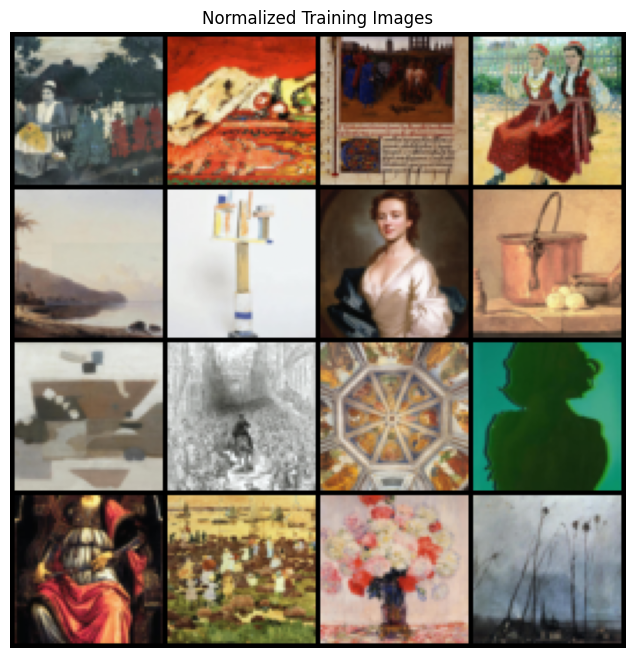

In [ ]:
def denorm(img_tensors):
    """Convert normalized tensors back to [0, 1] for visualization."""
    return img_tensors * 0.5 + 0.5

def show_images(images, num=16):
    plt.figure(figsize=(8,8))
    grid = torchvision.utils.make_grid(denorm(images[:num]), nrow=4)
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title("Normalized Training Images")
    plt.axis("off")
    plt.show()

show_images(images)

**Understanding the Output:**

In the visualization above, each image has been:
- Resized to **64×64 pixels**
- Converted to a tensor suitable for PyTorch models
- Normalized to the range **[-1, 1]**  

Even though the images may look slightly darker or lower in contrast, that’s expected — it simply means normalization worked correctly.

**Latent Vector Setup:**

Each training iteration will also generate a random latent vector $ z \in \mathbb{R}^{100} $.  
The Generator uses these noise vectors as its “creative spark,” learning how to map them into structured visual patterns over time.

In [ ]:
latent_dim = 100

# Sample a few random noise vectors
z = torch.randn(5, latent_dim)
print(f"Shape of latent noise vector z: {z.shape}")

Shape of latent noise vector z: torch.Size([5, 100])


At this stage, we’ve prepared both sides of our GAN training pipeline:
- **Real images** (normalized to match the tanh output range)
- **Random noise vectors** (latent space input for the Generator)

---

#### **Building a Minimal GAN Architecture**

To make our first GAN concrete, we will implement a **very shallow CNN** pair — a **Generator** that upsamples random noise into $64\times 64$ color images, and a **Discriminator** that judges whether an input image looks real or fake. We keep the design intentionally small so we can focus on the **adversarial idea** rather than heavy engineering.

**Design intuition we will follow**

- **Generator ($G$):** start from a latent vector $z\in\mathbb{R}^{100}$ sampled from $\mathcal{N}(0,1)$, then **upsample** with `ConvTranspose2d` blocks, using **ReLU** activations and a **$\tanh$** at the end so outputs live in $[-1,1]$ (matching our preprocessing).
- **Discriminator ($D$):** take a $64\times 64$ RGB image and **downsample** with `Conv2d` blocks, using **LeakyReLU** (slope $=0.2$) and a final **Sigmoid** to output a probability.

**Layer-by-layer shapes**

```text
Generator G (input: z ∈ ℝ^100)
z  → Linear → 128×8×8  → ReLU
   → ConvTranspose2d(128→64, k=4, s=2, p=1)  → 64×16×16  → ReLU
   → ConvTranspose2d(64→32,  k=4, s=2, p=1)  → 32×32×32  → ReLU
   → ConvTranspose2d(32→3,   k=4, s=2, p=1)  → 3×64×64   → Tanh  (range [-1, 1])

Discriminator D (input: image 3×64×64)
3×64×64  → Conv2d(3→32,  k=4, s=2, p=1)  → 32×32×32 → LeakyReLU(0.2)
         → Conv2d(32→64, k=4, s=2, p=1)  → 64×16×16 → LeakyReLU(0.2)
         → Conv2d(64→128,k=4, s=2, p=1)  → 128×8×8  → LeakyReLU(0.2)
         → Flatten → Linear(128·8·8 → 1) → Sigmoid (probability “real”)
```

**Why these activations?**

- In $G$, **ReLU** encourages strong, sparse feature activations during upsampling, while $\tanh$ maps pixel predictions to $[-1,1]$ to align with our normalized dataset.
- In $D$, **LeakyReLU** avoids “dead” neurons during downsampling and helps gradients flow even when activations are negative. Sigmoid outputs a calibrated probability $\in (0,1)$.

We also use the common **DCGAN weight initialization** heuristic: convolutional weights $\sim \mathcal{N}(0, 0.02^2)$, biases $=0$. This tends to stabilize early adversarial training.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
latent_dim = 100  # z ~ N(0,1)^100

# ---------------------------
# Generator
# ---------------------------
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(z_dim, 128*8*8),
            nn.ReLU(True)
        )
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 8→16
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 16→32
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # 32→64
            nn.Tanh()
        )

    def forward(self, z):
        x = self.project(z)                    # (N, 128*8*8)
        x = x.view(z.size(0), 128, 8, 8)       # (N, 128, 8, 8)
        x = self.upsample(x)                   # (N, 3, 64, 64)
        return x

# ---------------------------
# Discriminator
# ---------------------------
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # 64→32
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 32→16
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 16→8
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*8*8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.features(x)
        out = self.classifier(h)
        return out

# ------------------------------------------
# Weight initialization (DCGAN-style)
# ------------------------------------------
def init_weights(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1 or classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)

G = Generator(latent_dim).to(device)
D = Discriminator().to(device)
G.apply(init_weights)
D.apply(init_weights)

print(G)
print(D)

Generator(
  (project): Sequential(
    (0): Linear(in_features=100, out_features=8192, bias=True)
    (1): ReLU(inplace=True)
  )
  (upsample): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Tanh()
  )
)
Discriminator(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linea


- The **Generator** should end with an output of shape $[N, 3, 64, 64]$ and a final **$\tanh$** activation so pixel values are in $[-1, 1]$.
- The **Discriminator** should compress a $3\times 64\times 64$ image down to a **single probability** via **Sigmoid**.
- Both models are intentionally **small** so we can train short runs quickly and observe the adversarial dynamics.

Epoch [1/1] Batch [50/2546] D_loss: 0.0512  G_loss: 4.1303
Epoch [1/1] Batch [100/2546] D_loss: 0.7956  G_loss: 1.9118
Epoch [1/1] Batch [150/2546] D_loss: 0.2006  G_loss: 2.4077
Epoch [1/1] Batch [200/2546] D_loss: 1.2077  G_loss: 9.1052
Epoch [1/1] Batch [250/2546] D_loss: 0.2712  G_loss: 4.0892
Epoch [1/1] Batch [300/2546] D_loss: 0.0607  G_loss: 3.3909
Epoch [1/1] Batch [350/2546] D_loss: 0.1295  G_loss: 3.8964
Epoch [1/1] Batch [400/2546] D_loss: 0.5407  G_loss: 8.2280
Epoch [1/1] Batch [450/2546] D_loss: 0.5256  G_loss: 2.8947
Epoch [1/1] Batch [500/2546] D_loss: 0.6049  G_loss: 3.7545
Epoch [1/1] Batch [550/2546] D_loss: 0.2748  G_loss: 3.6159
Epoch [1/1] Batch [600/2546] D_loss: 0.3215  G_loss: 3.2197
Epoch [1/1] Batch [650/2546] D_loss: 0.1731  G_loss: 2.9155
Epoch [1/1] Batch [700/2546] D_loss: 2.6052  G_loss: 4.5176
Epoch [1/1] Batch [750/2546] D_loss: 0.2815  G_loss: 1.9255
Epoch [1/1] Batch [800/2546] D_loss: 0.8703  G_loss: 2.6357
Epoch [1/1] Batch [850/2546] D_loss: 0.17

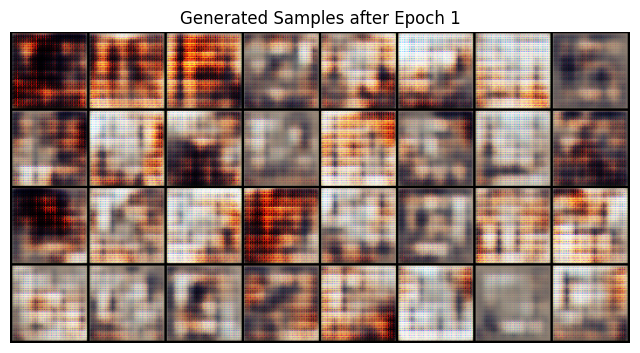

In [17]:
# Safety checks for variables defined in earlier sections
assert 'G' in globals() and 'D' in globals(), "Please run the model definition cell (Section 4) first."
assert 'data_loader' in globals(), "Please run the data loading cell (Section 2/3) first."
assert 'latent_dim' in globals(), "Please define latent_dim (e.g., latent_dim = 100) first."
device = "cuda" if torch.cuda.is_available() else "cpu"

# Loss and optimizers (DCGAN defaults for Adam)
criterion = nn.BCELoss()
lr = 2e-4
beta1 = 0.5
beta2 = 0.999
optimizerD = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))
optimizerG = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))

# Fixed noise for visualization across epochs
fixed_z = torch.randn(32, latent_dim, device=device)

# Utility: denormalize from [-1, 1] to [0, 1] for display
def denorm(x):
    return (x + 1) / 2

# Training parameters
epochs = 1
log_every = 50  # print frequency (batches)

G_losses, D_losses = [], []

for epoch in range(1, epochs + 1):
    G.train(); D.train()
    for i, (imgs, _) in enumerate(data_loader, start=1):
        # -------------------------
        # 1) Update Discriminator
        # -------------------------
        D.zero_grad()

        # Real images
        real = imgs.to(device)
        bsz = real.size(0)
        labels_real = torch.ones(bsz, 1, device=device)
        out_real = D(real)
        loss_real = criterion(out_real, labels_real)

        # Fake images (detach so gradients don't flow into G on D step)
        z = torch.randn(bsz, latent_dim, device=device)
        fake = G(z).detach()
        labels_fake = torch.zeros(bsz, 1, device=device)
        out_fake = D(fake)
        loss_fake = criterion(out_fake, labels_fake)

        # Total D loss and step
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()

        # -------------------------
        # 2) Update Generator
        # -------------------------
        G.zero_grad()

        z = torch.randn(bsz, latent_dim, device=device)
        gen = G(z)
        out = D(gen)
        # For G, we want D(gen) -> 1 (i.e., look real)
        labels_for_G = torch.ones(bsz, 1, device=device)
        loss_G = criterion(out, labels_for_G)
        loss_G.backward()
        optimizerG.step()

        # Logging
        if i % log_every == 0:
            print(f"Epoch [{epoch}/{epochs}] Batch [{i}/{len(data_loader)}] "
                  f"D_loss: {loss_D.item():.4f}  G_loss: {loss_G.item():.4f}")

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    # -------------------------
    # Visualize after each epoch
    # -------------------------
    G.eval()
    with torch.no_grad():
        samples = G(fixed_z).cpu()
    grid = torchvision.utils.make_grid(denorm(samples), nrow=8, padding=2)
    plt.figure(figsize=(8,8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.title(f"Generated Samples after Epoch {epoch}")
    plt.axis("off")
    plt.show()

In [18]:
torch.save(G.state_dict(), "dcgan_min_generator_final.pth")
torch.save(D.state_dict(), "dcgan_min_discriminator_final.pth")

#### **Understanding Adversarial Dynamics**

Now that we have seen our minimal GAN in action, it’s important that we pause and **understand what is really happening behind the scenes**. The training of a GAN is not a straightforward optimization; it’s a dynamic game between two neural networks — the **Generator ($G$)** and the **Discriminator ($D$)** — each with conflicting objectives.

**The adversarial balance**

In each iteration:
- $D$ learns to **maximize** the probability of correctly labeling real images as real and fake images as fake.
- $G$ learns to **minimize** that same probability — it wants $D(G(z))$ to approach 1 (real).

Formally, as we said before, this can be written as:

$$
\min_G \max_D V(D,G) = \mathbb{E}_{x\sim p_{data}}[\log D(x)] + \mathbb{E}_{z\sim p_z}[\log (1 - D(G(z)))]
$$

This forms a **two-player minimax game**, where each player’s progress depends on the other’s current strategy.  
If one improves too quickly, the other may fail to learn effectively.

**The need for balance**

A well-behaved GAN requires both $G$ and $D$ to learn at a comparable pace:

- If $D$ becomes **too strong**, it perfectly separates real and fake samples, giving gradients close to zero. The Generator stops learning — a phenomenon called **vanishing gradients**.
- If $G$ becomes **too strong**, it produces samples that easily fool $D$, so $D$ fails to recover meaningful signals about reality.
- The sweet spot is a **dynamic equilibrium**, where $G$ and $D$ continuously challenge each other but neither fully dominates.

This is why GAN training often requires careful tuning of learning rates, batch sizes, and update frequencies.

**Non-convergence and oscillation**

Unlike standard supervised learning, GANs do not necessarily **converge** to a fixed minimum.  
Because $G$ and $D$ are optimizing **opposing objectives**, the training tends to **oscillate** — loss values may fluctuate even when the quality of generated images improves.

A simplified intuition:
- $D$ learns to detect a flaw in $G$’s fake samples.
- $G$ adapts and fixes that flaw.
- Then $D$ finds a new flaw, restarting the cycle.

This **non-stationary objective** makes GANs both fascinating and challenging.